In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [5]:
class LinearRegressionGD:

    def __init__(self, learning_rate=0.01, n_iters=1000):
        self.learning_rate = learning_rate
        self.n_iters = n_iters
        self.theta_0 = 0
        self.theta_1 = 0
        self.sse_history = []

    def fit(self, X, y):
        X = np.array(X, dtype=float)
        y = np.array(y, dtype=float)
        self.X = X
        self.y = y
        m = len(X)

        for i in range(self.n_iters):
            y_pred = self.theta_0 + self.theta_1 * X
            error = y_pred - y

            sse = np.sum(error ** 2)
            self.sse_history.append(sse)

            grad_0 = (2 / m) * np.sum(error)
            grad_1 = (2 / m) * np.sum(error * X)

            self.theta_0 = self.theta_0 - self.learning_rate * grad_0
            self.theta_1 = self.theta_1 - self.learning_rate * grad_1

    def predict(self, X):
        X = np.array(X, dtype=float)
        return self.theta_0 + self.theta_1 * X

    def mse(self, X, y):
        error = self.predict(X) - np.array(y, dtype=float)
        return np.mean(error ** 2)

    def plot_training(self):
        plt.figure(figsize=(12, 4))

        plt.subplot(1, 2, 1)
        plt.plot(self.sse_history)
        plt.title("SSE over iterations")
        plt.xlabel("Iteration")
        plt.ylabel("SSE")

        plt.subplot(1, 2, 2)
        plt.scatter(self.X, self.y, label="Data")
        plt.plot(self.X, self.predict(self.X), color="red", label="Regression line")
        plt.title("Regression line")
        plt.xlabel("Size (m²)")
        plt.ylabel("Price")
        plt.legend()

        plt.show()

In [6]:
print([name for name in dir(LinearRegressionGD) if not name.startswith("_")])

['fit', 'mse', 'plot_training', 'predict']


In [12]:
X = [50, 60, 70, 80, 90]     
y = [150, 180, 210, 240, 270]   
X = np.array(X)
y = np.array(y)
print("X =", X)
print("y =", y)
print("Shape of X", X.shape)
print("Shape of y", y.shape)

X = [50 60 70 80 90]
y = [150 180 210 240 270]
Shape of X (5,)
Shape of y (5,)


### Question: Explain what X and y represent??/

X : represents the size of the house in square meters (m²). It is the feature = that the model uses to make predictions(inouuut)
y : represents the price of the house in thousands. It is the target that the model tries to predict(outpuuutt)

The goal of the model is to learn the relationship between X and y so that it can predict the price of a house from its size

In [11]:
model = LinearRegressionGD(learning_rate=0.001, n_iters=100)
model.fit(X, y)

print("theta_0 ", model.theta_0)
print("theta_1 ", model.theta_1)

theta_0  -1.0055957901462392e+95
theta_1  -7.326427288635144e+96


In [ ]:
pred = model.predict(70)
print("predicted price for 70 m²", pred)
print("actual price in dataset", 210)

Predicted price for 70 m²: -5.129504697834747e+98
Actual price in the dataset: 210


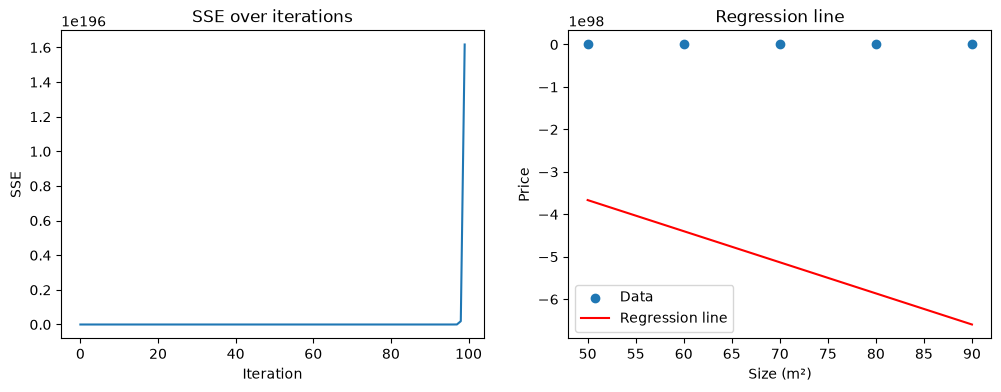

In [13]:
model.plot_training()

theta_0 = 209.99999995722223
theta_1 = 42.426406862550444
Predicted price for 70 m² 209.99999995722223


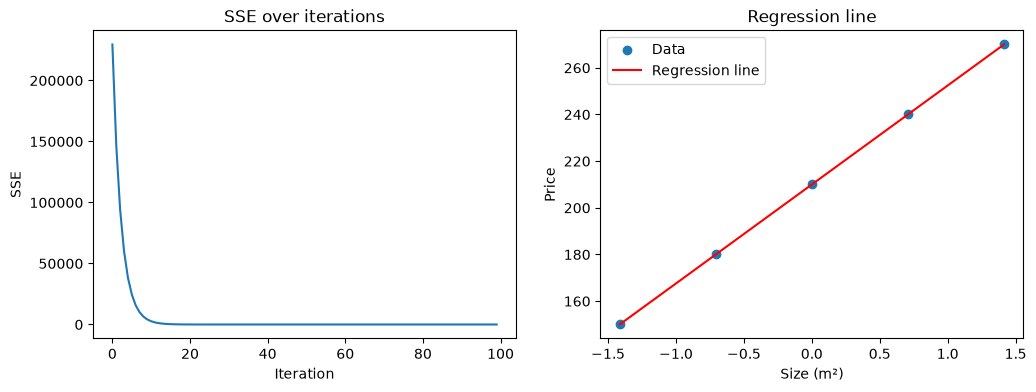

In [17]:
mu = X.mean()    
sigma = X.std()     
X_norm = (X - mu) / sigma

model_n = LinearRegressionGD(learning_rate=0.1, n_iters=100)
model_n.fit(X_norm, y)

print("theta_0 =", model_n.theta_0)
print("theta_1 =", model_n.theta_1)

size_70 = (70 - mu) / sigma
print("Predicted price for 70 m²", model_n.predict(size_70))

# 4) Plots
model_n.plot_training()

small (1e-6)
  theta_0 = 0.026403782164981494
  theta_1 = 1.923712864802833
  Final SSE = 30130.80602713573

good (1e-4)
  theta_0 = 0.04113676040970018
  theta_1 = 2.999435373457505
  Final SSE = 0.00033181560776546876

large (1e-3)
  theta_0 = -1.0055957901462392e+95
  theta_1 = -7.326427288635144e+96
  Final SSE = 1.6170789775172399e+196



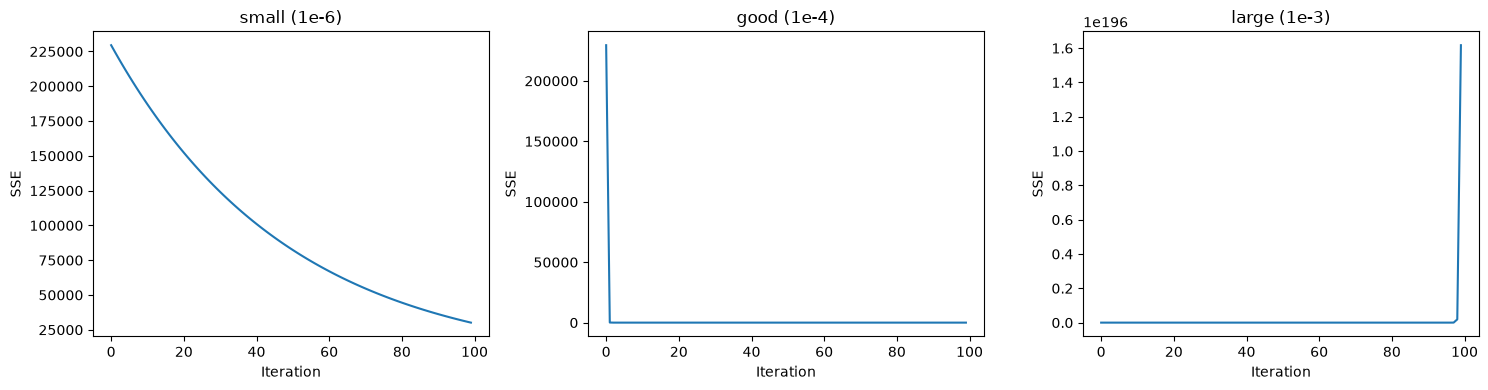

In [18]:
learning_rates = [0.000001, 0.0001, 0.001]
names = ["small (1e-6)", "good (1e-4)", "large (1e-3)"]

plt.figure(figsize=(15, 4))

for i in range(3):
    m = LinearRegressionGD(learning_rate=learning_rates[i], n_iters=100)
    m.fit(X, y)

    print(names[i])
    print("  theta_0 =", m.theta_0)
    print("  theta_1 =", m.theta_1)
    print("  Final SSE =", m.sse_history[-1])
    print()

    plt.subplot(1, 3, i + 1)
    plt.plot(m.sse_history)
    plt.title(names[i])
    plt.xlabel("Iteration")
    plt.ylabel("SSE")

plt.tight_layout()
plt.show()